In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [7]:
df.describe(include = "object")

,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3186-AJIEK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192


df.isnull().sum()

In [8]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [9]:
df["Churn Reason"].tail(10)

7033    NaN
7034    NaN
7035    NaN
7036    NaN
7037    NaN
7038    NaN
7039    NaN
7040    NaN
7041    NaN
7042    NaN
Name: Churn Reason, dtype: object

In [10]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

## 1. Dataset Overview

The dataset contains customer-level information related to
demographics, location, subscribed services, account information,
billing and churn.

Each row represents one customer.

The target variable for this analysis is Churn Label.

In [11]:
df["Churn Label"].value_counts(normalize = True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

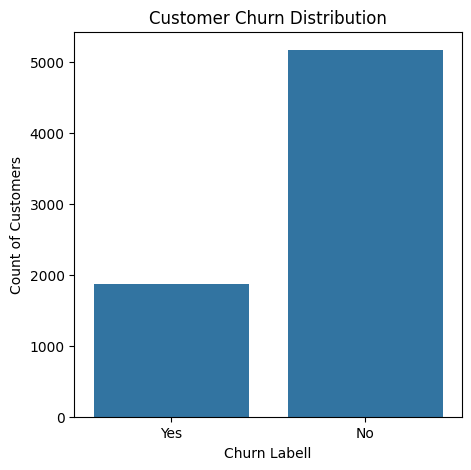

In [12]:
plt.figure(figsize = (5, 5))
sns.countplot(df, x = "Churn Label")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Labell")
plt.ylabel("Count of Customers")
plt.show()

In [13]:
pd.crosstab(df['Churn Label'], df['Churn Value'])

Churn Value,0,1
Churn Label,,
No,5174,0
Yes,0,1869


In [14]:
df.groupby("Churn Label")["Churn Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,50.098183,17.702277,5.0,35.0,50.0,66.0,80.0
Yes,1869.0,82.510433,10.328570,65.0,74.0,82.0,91.0,100.0


In [15]:
df["Churn Reason"].value_counts()

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [16]:
df["CustomerID"].duplicated().sum()

np.int64(0)

In [17]:
missing = pd.DataFrame(
    {
        "Missing Values" : df.isnull().sum(),
        "Missing %" : (df.isnull().sum() / len(df)) * 100
    }
)
missing.sort_values("Missing Values", ascending = False)

,Missing Values,Missing %
Churn Reason,5174,73.463013
CustomerID,0,0.000000
Count,0,0.000000
State,0,0.000000
Country,0,0.000000
Zip Code,0,0.000000
Lat Long,0,0.000000
Latitude,0,0.000000
City,0,0.000000
Gender,0,0.000000


In [18]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [19]:
churn_by_contract = pd.DataFrame(df.groupby("Contract")["Churn Value"].sum())

In [20]:
churn_by_contract

,Churn Value
Contract,
Month-to-month,1655
One year,166
Two year,48


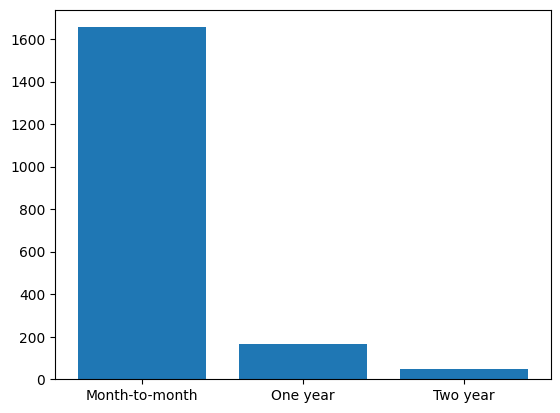

In [21]:
labelss = churn_by_contract.index
values = churn_by_contract["Churn Value"]

plt.bar(labelss, values)
plt.show()

In [22]:
df['Total Charges'].astype(str).str.strip().eq('').sum()

np.int64(11)

In [23]:
df[df['Total Charges'].astype(str).str.strip() == ''][[
    'CustomerID',
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'Churn Label'
]]

,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,,No
2438,3115-CZMZD,0,20.25,,No
2568,5709-LVOEQ,0,80.85,,No
2667,4367-NUYAO,0,25.75,,No
2856,1371-DWPAZ,0,56.05,,No
4331,7644-OMVMY,0,19.85,,No
4687,3213-VVOLG,0,25.35,,No
5104,2520-SGTTA,0,20.00,,No
5719,2923-ARZLG,0,19.70,,No
6772,4075-WKNIU,0,73.35,,No


In [24]:
df["Total Charges"].dtypes

dtype('O')

In [25]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [26]:
df['Total Charges'].dtype

dtype('float64')

In [27]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [28]:
df[df['Total Charges'].isnull()][[
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
    'Churn Label'
]]

,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,0,52.55,NaN,No
2438,0,20.25,NaN,No
2568,0,80.85,NaN,No
2667,0,25.75,NaN,No
2856,0,56.05,NaN,No
4331,0,19.85,NaN,No
4687,0,25.35,NaN,No
5104,0,20.00,NaN,No
5719,0,19.70,NaN,No
6772,0,73.35,NaN,No


In [29]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [30]:
df[df['Total Charges'].isnull()]['Tenure Months'].value_counts()

Tenure Months
0    11
Name: count, dtype: int64

In [31]:
df[df['Total Charges'].isnull()]['Churn Label'].value_counts()

Churn Label
No    11
Name: count, dtype: int64

In [32]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'   # converts values that cannot be converted into NaN
)

In [33]:
df['Total Charges'].dtype

dtype('float64')

In [34]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [35]:
df.loc[
    (df['Total Charges'].isnull()) &
    (df['Tenure Months'] == 0),
    'Total Charges'
] = 0

In [36]:
df['Total Charges'].isnull().sum()

np.int64(0)

### Handling Missing Total Charges

The Total Charges column contained missing values. Investigation
showed that these records corresponded to customers with zero
tenure months. Therefore, these missing total charge values were
treated as 0 rather than using a statistical estimate.

In [37]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': df.isnull().sum() / len(df) * 100
})

missing = missing[missing['Missing Values'] > 0]

missing.sort_values('Missing Values', ascending=False)

,Missing Values,Missing Percentage
Churn Reason,5174,73.463013


In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df["CustomerID"].duplicated().sum()

np.int64(0)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [41]:
print(df['Contract'].value_counts())
print("\n--------------\n", df['Internet Service'].value_counts())
print("\n--------------\n", df['Payment Method'].value_counts())
print("\n--------------\n", df['Phone Service'].value_counts())
print("\n--------------\n", df['Tech Support'].value_counts())
print("\n--------------\n", df['Online Security'].value_counts())

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

--------------
 Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--------------
 Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

--------------
 Phone Service
Yes    6361
No      682
Name: count, dtype: int64

--------------
 Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

--------------
 Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


In [42]:
clean_df = df.copy()

In [43]:
clean_df.shape

(7043, 33)

In [44]:
clean_df['Churn Label'].value_counts(normalize = True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [45]:
churn_rate = (
    clean_df['Churn Label'].eq('Yes').mean() * 100
)

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


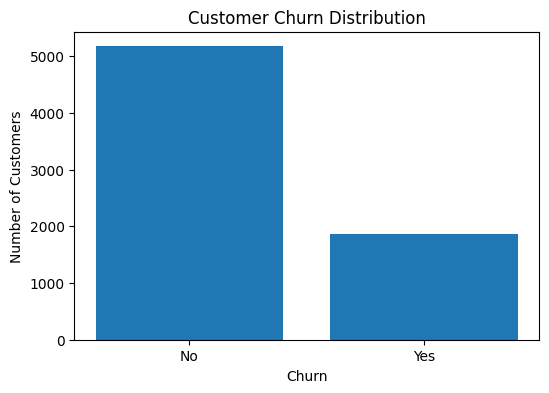

In [46]:
churn_counts = clean_df['Churn Label'].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [47]:
contract_churn = pd.crosstab(
    clean_df['Contract'],
    clean_df['Churn Label']
)

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [48]:
contract_churn_rate = (
    clean_df.groupby('Contract')['Churn Value']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

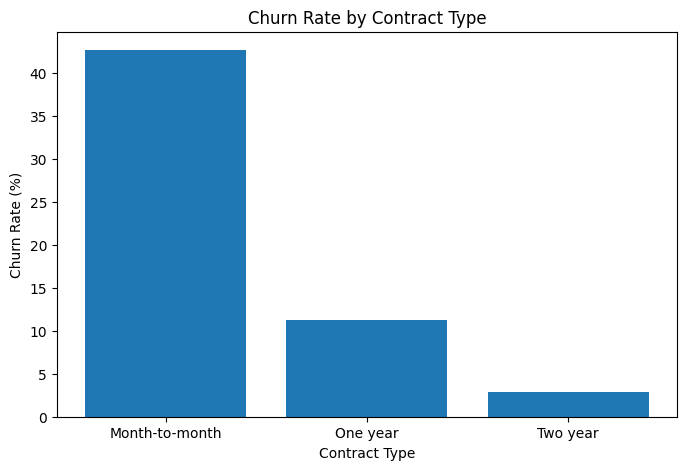

In [49]:
plt.figure(figsize=(8, 5))

plt.bar(
    contract_churn_rate.index,
    contract_churn_rate.values
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.show()

### Finding

The churn rate differs across contract types. The contract category
with the highest churn rate is Month-to-month, while the category with the
lowest churn rate is two year.

This indicates that contract type is associated with customer churn
in this dataset.

### Business Interpretation

Customers in the Month-to-month contract category may require greater
attention from the retention team. However, this analysis shows an
association and does not establish that contract type directly causes
churn.

In [50]:
clean_df.groupby("Churn Label")["Tenure Months"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


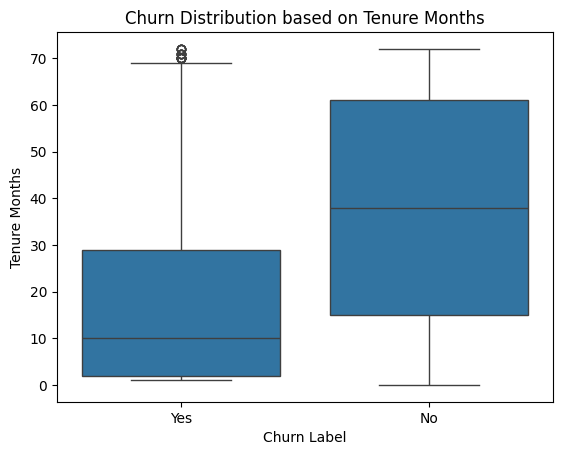

In [51]:
plt.figsize = (10, 5)

sns.boxplot(data = clean_df, x = "Churn Label", y = "Tenure Months")

plt.xlabel("Churn Label")
plt.ylabel("Tenure Months")
plt.title("Churn Distribution based on Tenure Months")
plt.show()

In [52]:
bins_range = [0, 12, 24, 48, 60, np.inf]

labelss = ["0-12 months", "13-24 months", "25-48 months", "49-60 months", "60+ months"]

clean_df["Tenure Groups"] = pd.cut(clean_df["Tenure Months"], bins = bins_range, labels = labelss, include_lowest = True)

In [53]:
clean_df["Tenure Groups"].value_counts().sort_index()

Tenure Groups
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-60 months     832
60+ months      1407
Name: count, dtype: int64

In [54]:
tenure_churn_rate = (
    clean_df.groupby('Tenure Groups', observed=True)['Churn Value']
    .mean()
    .mul(100)
)

tenure_churn_rate

Tenure Groups
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-60 months    14.423077
60+ months       6.609808
Name: Churn Value, dtype: float64

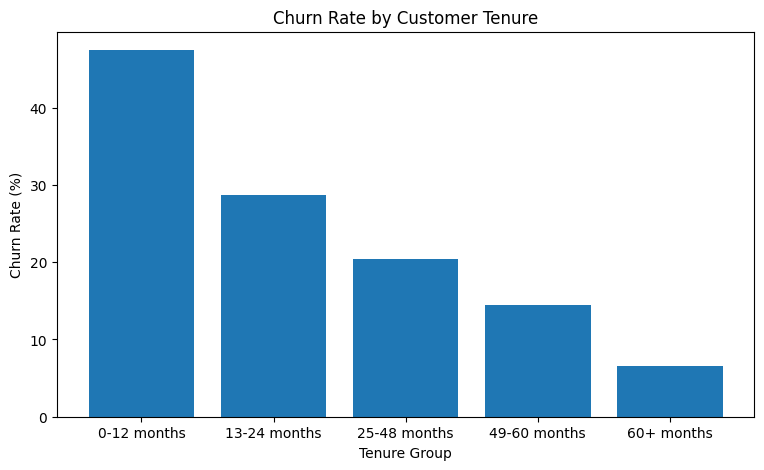

In [55]:
plt.figure(figsize=(9, 5))

plt.bar(
    tenure_churn_rate.index.astype(str),
    tenure_churn_rate.values
)

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')

plt.show()

### Finding

The churn rate varies across customer tenure groups. The 0-12
group has the highest churn rate, while the 60+ group has the
lowest churn rate.

### Business Interpretation

The results suggest that customer tenure is associated with churn
in this dataset. This may indicate that particular stages of the
customer lifecycle deserve additional retention attention.

### Limitation

The analysis identifies an association between tenure and churn.
It does not establish that tenure itself causes customers to churn.

In [56]:
clean_df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Tenure Groups
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,0-12 months
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,0-12 months
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,0-12 months
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,25-48 months
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,49-60 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN,60+ months
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN,13-24 months
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN,60+ months
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN,0-12 months


In [57]:
clean_df["Monthly Charges"].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [58]:
clean_df.groupby("Churn Label")["Monthly Charges"].mean()

Churn Label
No     61.265124
Yes    74.441332
Name: Monthly Charges, dtype: float64

In [59]:
clean_df.groupby("Churn Label")["Monthly Charges"].median()

Churn Label
No     64.425
Yes    79.650
Name: Monthly Charges, dtype: float64

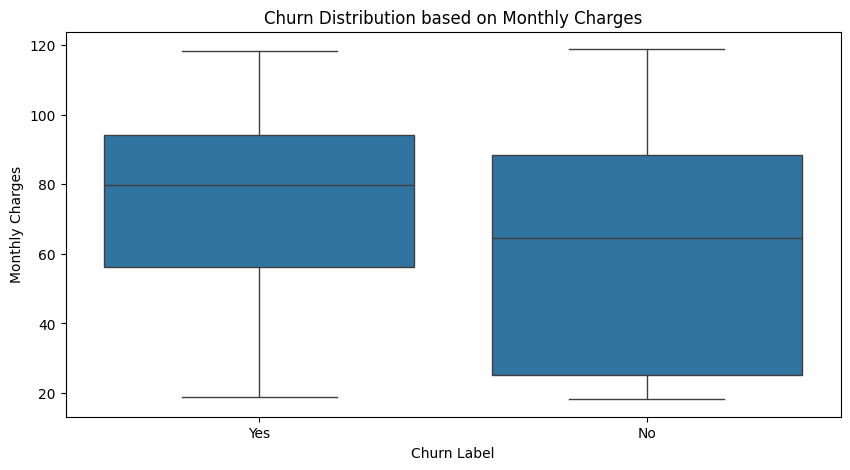

In [60]:
plt.figure(figsize = (10, 5))

sns.boxplot(data = clean_df, x = "Churn Label", y = "Monthly Charges")

plt.title("Churn Distribution based on Monthly Charges")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charges")
plt.show()

In [61]:
clean_df['Monthly Charge Group'] = pd.qcut(
    clean_df['Monthly Charges'],
    q=4,
    duplicates='drop'
)

In [62]:
clean_df['Monthly Charge Group'].value_counts().sort_index()

Monthly Charge Group
(18.249, 35.5]     1762
(35.5, 70.35]      1766
(70.35, 89.85]     1757
(89.85, 118.75]    1758
Name: count, dtype: int64

In [63]:
clean_df['Monthly Charge Group'] = pd.qcut(
    clean_df['Monthly Charges'],
    q=4,
    labels=[
        'Low',
        'Medium-Low',
        'Medium-High',
        'High'
    ]
)

In [64]:
charge_churn_rate = (clean_df.groupby("Monthly Charge Group", observed = True)["Churn Value"].mean().mul(100))
charge_churn_rate

Monthly Charge Group
Low            11.237230
Medium-Low     24.575311
Medium-High    37.507114
High           32.878271
Name: Churn Value, dtype: float64

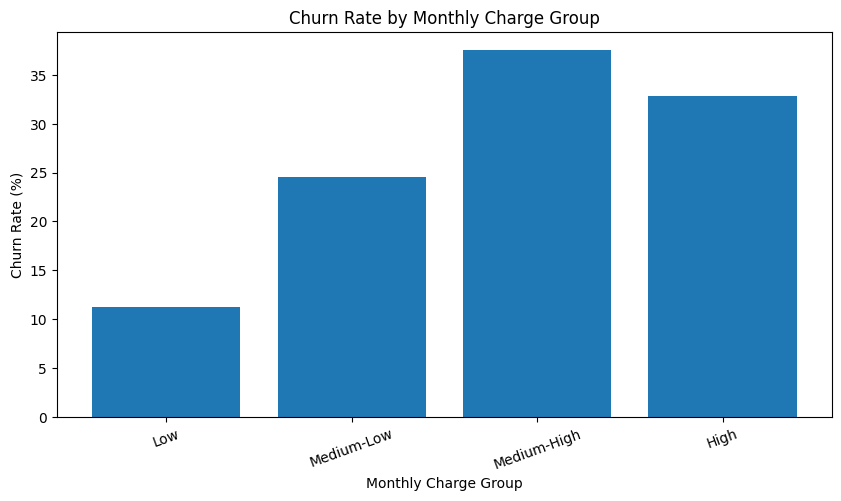

In [65]:
plt.figure(figsize=(10, 5))

plt.bar(
    charge_churn_rate.index.astype(str),
    charge_churn_rate.values
)

plt.title('Churn Rate by Monthly Charge Group')
plt.xlabel('Monthly Charge Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=20)

plt.show()

### Finding

The churn rate varies across monthly charge groups. The Medium-High(70.35,89.85)
charge group has the highest churn rate, while the Low(18.249, 35.5) group
has the lowest churn rate.

### Business Interpretation

The results suggest that monthly charges are associated with
customer churn in this dataset. Customers in certain charge ranges
may require additional investigation to understand whether pricing,
service combinations, or other factors contribute to their churn.

### Limitation

Monthly charges may be related to other variables such as contract
type and subscribed services. Therefore, the observed relationship
should not be interpreted as evidence that higher charges directly
cause churn.

In [66]:
clean_df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Tenure Groups,Monthly Charge Group
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,0-12 months,Medium-Low
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,0-12 months,Medium-High
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,0-12 months,High
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,25-48 months,High
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,49-60 months,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN,60+ months,Low
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,Mailed check,84.80,1990.50,No,0,59,2140,NaN,13-24 months,Medium-High
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN,60+ months,High
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Electronic check,29.60,346.45,No,0,59,2793,NaN,0-12 months,Low


In [67]:
clean_df["Internet Service"].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [68]:
internet_services_churn_rate = (clean_df.groupby("Internet Service")["Churn Value"].mean().mul(100))

In [69]:
internet_services_churn_rate

Internet Service
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn Value, dtype: float64

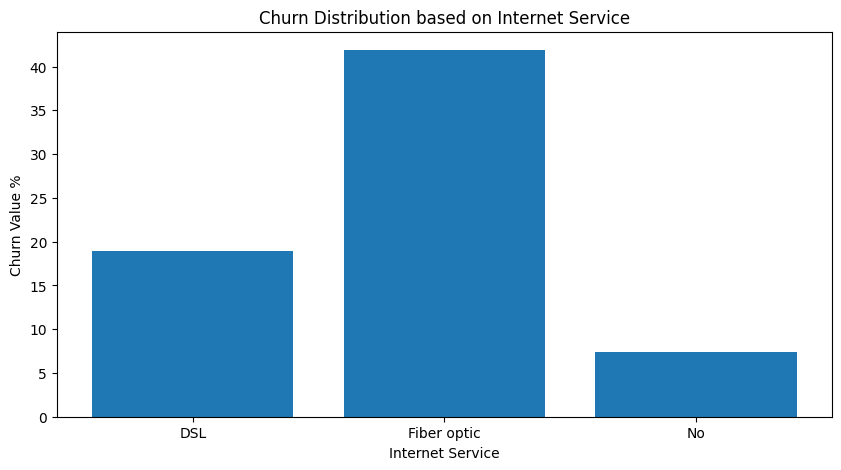

In [70]:
plt.figure(figsize = (10, 5))

plt.bar(internet_services_churn_rate.index,
       internet_services_churn_rate.values,
       )

plt.title("Churn Distribution based on Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Value %")
plt.show()

### Finding

Churn rates differ substantially across internet service types.
Fiber optic customers have the highest churn rate at approximately
42%, while customers without internet service have the lowest churn
rate at approximately 7%.

### Interpretation

Internet service type is associated with customer churn in this
dataset. Fiber optic customers may require further investigation
to understand whether pricing, service quality, contract type, or
other factors are related to their higher churn rate.

### Limitation

This analysis shows an association and does not establish that the
internet service itself causes customers to churn.

In [71]:
clean_df["Payment Method"].value_counts()

Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [72]:
payment_churn_percentage = clean_df.groupby("Payment Method")["Churn Value"].mean().mul(100)

In [73]:
payment_churn_percentage

Payment Method
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn Value, dtype: float64

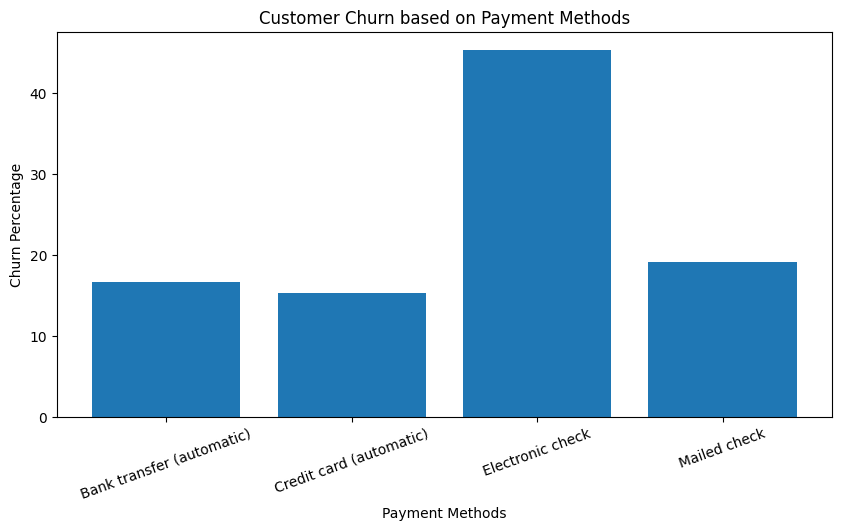

In [74]:
plt.figure(figsize = (10, 5))

plt.bar(payment_churn_percentage.index,
       payment_churn_percentage.values)

plt.title("Customer Churn based on Payment Methods")
plt.xlabel("Payment Methods")
plt.ylabel("Churn Percentage")

plt.xticks(rotation=20)
plt.show()

### Finding

Churn rates differ across payment methods. Customers using electronic
check have the highest churn rate, at approximately 45%, while
customers using automatic credit card payments have the lowest churn
rate, at approximately 15%.

### Interpretation

Payment method is associated with customer churn in this dataset.
The high churn rate among electronic-check customers may warrant
further investigation into payment experience or related customer
characteristics.

### Limitation

Payment method alone does not establish the reason for churn.
Other factors such as contract type, tenure, internet service and
monthly charges may also be related to the observed difference.

In [75]:
clean_df["Tech Support"].value_counts()

Tech Support
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [76]:
techsupport_churn_percentage = (clean_df.groupby("Tech Support")["Churn Value"].mean().mul(100))

In [77]:
techsupport_churn_percentage

Tech Support
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn Value, dtype: float64

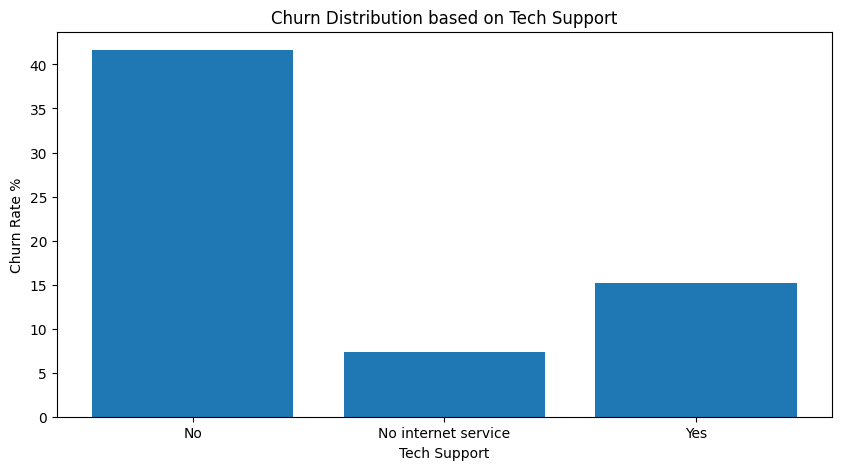

In [78]:
plt.figure(figsize = (10, 5))

plt.bar(techsupport_churn_percentage.index, techsupport_churn_percentage.values)

plt.title("Churn Distribution based on Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate %")

plt.show()

### Finding

Customers without tech support have a much higher churn rate than
customers with tech support. The churn rate is approximately 42%
for customers without tech support compared with approximately 15%
for customers with tech support.

### Interpretation

Tech support availability is associated with customer churn in this
dataset. Customers without tech support may require additional
attention from the retention team.

### Limitation

This is an association and does not prove that providing tech
support directly prevents churn. Other factors, such as internet
service, contract type and tenure, may also influence the result.

In [79]:
clean_df["Online Security"].value_counts()

Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [80]:
security_churn_rate = (
    clean_df.groupby('Online Security')['Churn Value']
    .mean()
    .mul(100)
)

security_churn_rate

Online Security
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn Value, dtype: float64

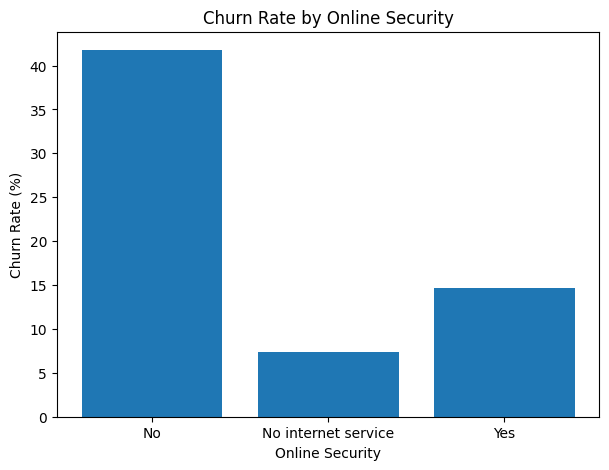

In [81]:
plt.figure(figsize=(7, 5))

plt.bar(
    security_churn_rate.index,
    security_churn_rate.values
)

plt.title('Churn Rate by Online Security')
plt.xlabel('Online Security')
plt.ylabel('Churn Rate (%)')

plt.show()

In [82]:
clean_df["Senior Citizen"].value_counts(ascending = True)

Senior Citizen
Yes    1142
No     5901
Name: count, dtype: int64

In [83]:
senior_churn_rate = clean_df.groupby("Senior Citizen")["Churn Value"].mean().mul(100)

In [84]:
senior_churn_rate

Senior Citizen
No     23.606168
Yes    41.681261
Name: Churn Value, dtype: float64

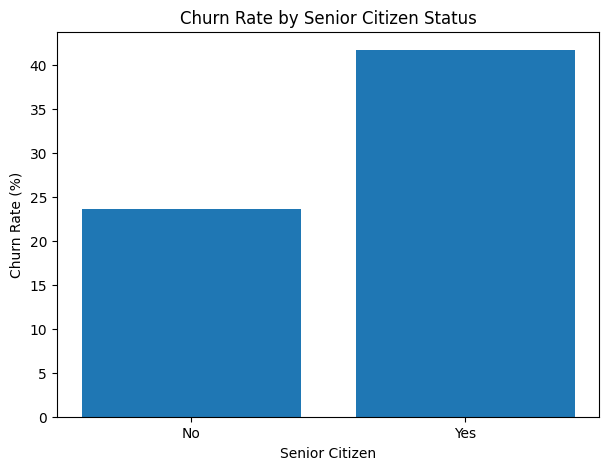

In [85]:
plt.figure(figsize=(7, 5))

plt.bar(
    senior_churn_rate.index.astype(str),
    senior_churn_rate.values
)

plt.title('Churn Rate by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')

plt.show()

In [86]:
clean_df.groupby('Partner')['Churn Value'].mean().mul(100)

Partner
No     32.957979
Yes    19.664903
Name: Churn Value, dtype: float64

In [87]:
clean_df.groupby('Dependents')['Churn Value'].mean().mul(100)

Dependents
No     32.551699
Yes     6.515058
Name: Churn Value, dtype: float64

In [88]:
churned_df = clean_df[clean_df["Churn Label"] == "Yes"]

In [89]:
churned_df.shape

(1869, 35)

In [90]:
churn_reasons = churned_df['Churn Reason'].value_counts()

churn_reasons

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [91]:
churn_reason_percent = churned_df["Churn Reason"].value_counts(normalize = True).mul(100)

In [92]:
churn_reason_percent

Churn Reason
Attitude of support person                   10.272873
Competitor offered higher download speeds    10.112360
Competitor offered more data                  8.667737
Don't know                                    8.239700
Competitor made better offer                  7.490637
Attitude of service provider                  7.223114
Competitor had better devices                 6.955591
Network reliability                           5.510968
Product dissatisfaction                       5.457464
Price too high                                5.243446
Service dissatisfaction                       4.761905
Lack of self-service on Website               4.708400
Extra data charges                            3.049759
Moved                                         2.835741
Lack of affordable download/upload speed      2.354200
Limited range of services                     2.354200
Long distance charges                         2.354200
Poor expertise of phone support               1.0700

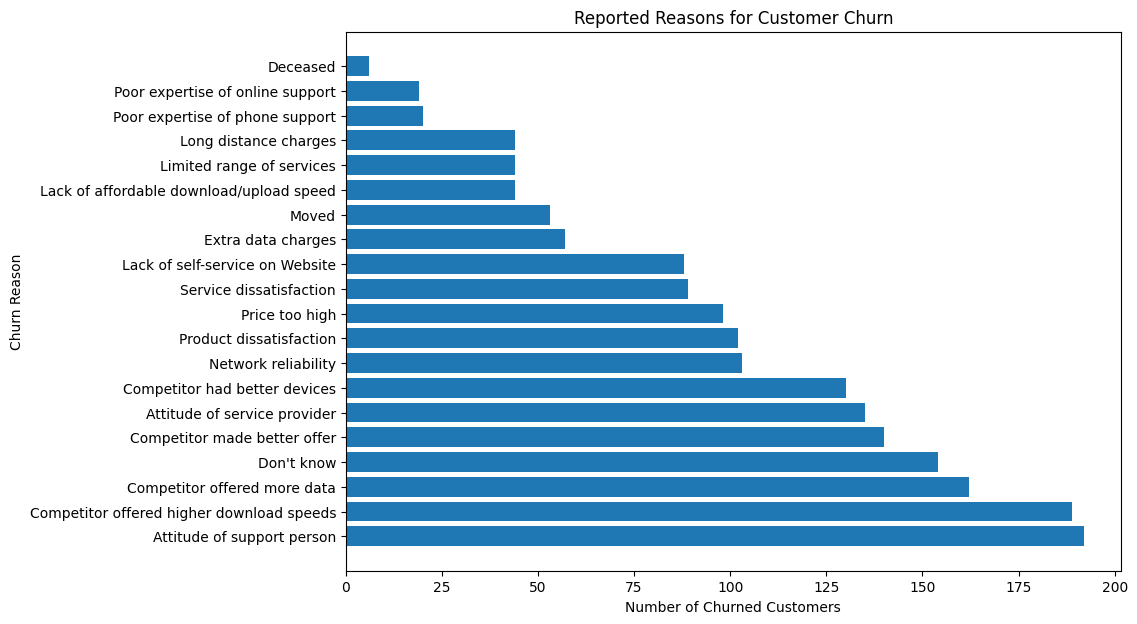

In [93]:
plt.figure(figsize=(10, 7))

plt.barh(
    churn_reasons.index,
    churn_reasons.values
)

plt.title('Reported Reasons for Customer Churn')
plt.xlabel('Number of Churned Customers')
plt.ylabel('Churn Reason')

plt.show()

### Finding

Among customers who churned, the most frequently reported reasons
include attitude of the support person, competitors offering higher
download speeds, competitors offering more data, and customers who
did not know the specific reason for leaving.

### Business Interpretation

The reported reasons suggest that customer experience, service
quality, and competitive offerings may be important areas for the
business to investigate for retention.

### Limitation

These are reasons reported by customers who already churned. They
should not be interpreted as proof that these factors caused churn.

**SEGMENTATION = Dividing customers into meaningful groups**

In [98]:
segment = (clean_df.groupby(["Contract", "Tenure Groups"], observed = True)
           .agg(Customers = ("CustomerID", "count"), Churned = ("Churn Value", "sum")
))
segment["Churn Rate %"] = (segment["Churned"] / segment["Customers"] * 100)

segment.sort_values("Churn Rate %", ascending = False)

Customers  Churned  Churn Rate %
Contract       Tenure Groups                                  
Month-to-month 0-12 months         1994     1024     51.354062
               13-24 months         737      278     37.720488
               25-48 months         802      264     32.917706
               49-60 months         234       65     27.777778
               60+ months           108       24     22.222222
One year       49-60 months         321       44     13.707165
               60+ months           313       38     12.140575
               25-48 months         518       55     10.617761
               0-12 months          124       13     10.483871
               13-24 months         197       16      8.121827
Two year       49-60 months         277       11      3.971119
               60+ months           986       31      3.144016
               25-48 months         274        6      2.189781
               0-12 months           68        0      0.000000
               13-24 months          90        0      0.000000

In [99]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    clean_df['Contract'],
    clean_df['Churn Label']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 1184.5965720837926
p-value: 5.863038300673391e-258


In [101]:
features = [
    'Contract',
    'Internet Service',
    'Payment Method',
    'Tech Support',
    'Online Security',
    'Senior Citizen'
]

results = []

for feature in features:
    table = pd.crosstab(
        clean_df[feature],
        clean_df['Churn Label']
    )

    chi2, p, dof, expected = chi2_contingency(table)

    results.append([feature, chi2, p])

chi_results = pd.DataFrame(
    results,
    columns=['Feature', 'Chi-square', 'p-value']
)

chi_results

,Feature,Chi-square,p-value
0,Contract,1184.596572,5.863038e-258
1,Internet Service,732.309590,9.571788e-160
2,Payment Method,648.142327,3.682355e-140
3,Tech Support,828.197068,1.443084e-180
4,Online Security,849.998968,2.661150e-185
5,Senior Citizen,159.426300,1.510067e-36


### Statistical Validation

Chi-square tests were performed to examine the association between
selected categorical variables and customer churn.

All tested variables produced p-values below 0.05, indicating
statistically significant associations with churn in this dataset.

However, statistical significance does not imply causation or
indicate the practical importance of a variable. Therefore, these
results are considered alongside the observed churn rates and
business context.

In [103]:
chi_results

,Feature,Chi-square,p-value
0,Contract,1184.596572,5.863038e-258
1,Internet Service,732.309590,9.571788e-160
2,Payment Method,648.142327,3.682355e-140
3,Tech Support,828.197068,1.443084e-180
4,Online Security,849.998968,2.661150e-185
5,Senior Citizen,159.426300,1.510067e-36


In [104]:
overall_churn = clean_df['Churn Value'].mean() * 100
print(f"Overall churn rate: {overall_churn:.2f}%")

Overall churn rate: 26.54%


In [105]:
contract_churn_rate = (
    clean_df.groupby('Contract')['Churn Value']
    .mean()
    .mul(100)
)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

In [119]:
print("OVERALL CHURN")
print(f"{clean_df['Churn Value'].mean() * 100:.2f}%")

print("\nCONTRACT")
print(contract_churn_rate)

print("\nTENURE")
print(tenure_churn_rate)

print("\nMONTHLY CHARGES")
print(charge_churn_rate)

print("\nINTERNET SERVICE")
print(internet_services_churn_rate)

print("\nPAYMENT METHOD")
print(payment_churn_percentage)

print("\nTECH SUPPORT")
print(techsupport_churn_percentage)

print("\nONLINE SECURITY")
print(security_churn_rate)

print("\nSENIOR CITIZEN")
print(senior_churn_rate)

print("\nTOP CHURN REASONS")
print(churn_reason_percent.head(10))

OVERALL CHURN
26.54%

CONTRACT
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

TENURE
Tenure Groups
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-60 months    14.423077
60+ months       6.609808
Name: Churn Value, dtype: float64

MONTHLY CHARGES
Monthly Charge Group
Low            11.237230
Medium-Low     24.575311
Medium-High    37.507114
High           32.878271
Name: Churn Value, dtype: float64

INTERNET SERVICE
Internet Service
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn Value, dtype: float64

PAYMENT METHOD
Payment Method
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn Value, dtype: float64

TECH SUPPORT
Tech Support
No                     41.635474
No internet service     7.404980
Yes                    15.

In [120]:
key_findings = pd.DataFrame({
    'Area': [
        'Tech Support',
        'Online Security',
        'Senior Citizen',
        'Churn Reasons'
    ],
    'Finding': [
        'Customers without tech support have a much higher churn rate.',
        'Customers without online security have a much higher churn rate.',
        'Senior citizens have a higher churn rate than non-senior customers.',
        'Support experience and competitor offerings are among the most frequently reported churn reasons.'
    ],
    'Evidence': [
        '41.63% vs 15.17%',
        '41.77% vs 14.61%',
        '41.68% vs 23.61%',
        '10.27%, 10.11%, and 8.67% respectively'
    ]
})

key_findings

,Area,Finding,Evidence
0,Tech Support,Customers without tech support have a much hig...,41.63% vs 15.17%
1,Online Security,Customers without online security have a much ...,41.77% vs 14.61%
2,Senior Citizen,Senior citizens have a higher churn rate than ...,41.68% vs 23.61%
3,Churn Reasons,Support experience and competitor offerings ar...,"10.27%, 10.11%, and 8.67% respectively"


In [123]:
print("CONTRACT")
print(contract_churn_rate)

print("\nTENURE")
print(tenure_churn_rate)

print("\nMONTHLY CHARGES")
print(charge_churn_rate)

print("\nINTERNET SERVICE")
print(internet_services_churn_rate)

print("\nPAYMENT METHOD")
print(payment_churn_percentage)

CONTRACT
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn Value, dtype: float64

TENURE
Tenure Groups
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-60 months    14.423077
60+ months       6.609808
Name: Churn Value, dtype: float64

MONTHLY CHARGES
Monthly Charge Group
Low            11.237230
Medium-Low     24.575311
Medium-High    37.507114
High           32.878271
Name: Churn Value, dtype: float64

INTERNET SERVICE
Internet Service
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn Value, dtype: float64

PAYMENT METHOD
Payment Method
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn Value, dtype: float64


In [125]:
segment.sort_values(
    'Churn Rate %',
    ascending=False
).head(10)

Customers  Churned  Churn Rate %
Contract       Tenure Groups                                  
Month-to-month 0-12 months         1994     1024     51.354062
               13-24 months         737      278     37.720488
               25-48 months         802      264     32.917706
               49-60 months         234       65     27.777778
               60+ months           108       24     22.222222
One year       49-60 months         321       44     13.707165
               60+ months           313       38     12.140575
               25-48 months         518       55     10.617761
               0-12 months          124       13     10.483871
               13-24 months         197       16      8.121827

### Customer Segmentation Finding

The segmentation analysis shows that month-to-month customers have
elevated churn rates across all tenure groups. The highest observed
churn rate is among customers with month-to-month contracts and
0–12 months of tenure, where 51.35% of customers churned.

Churn decreases as tenure increases within the month-to-month
segment, although the churn rate remains higher than the longer-term
contract segments shown in the analysis.

## Key Findings

1. Customers with 0–12 months of tenure have the highest overall
   churn rate at 47.44%.

2. Month-to-month contract customers have a churn rate of 42.71%,
   compared with 2.83% for two-year contract customers.

3. The month-to-month + 0–12 months segment has the highest observed
   churn rate at 51.35%, with 1,024 out of 1,994 customers churning.

4. Churn is higher in the medium-high and high monthly-charge groups
   than in the low-charge group.

5. Fiber optic customers and electronic-check customers show
   substantially higher churn rates than other categories.

6. Customers without Tech Support or Online Security have churn
   rates above 40%, compared with around 15% among customers with
   these services.

7. Among churned customers, frequently reported reasons include
   attitude of support person, competitors offering higher download
   speeds, and competitors offering more data.

## Retention Recommendations

### 1. Strengthen Early-Customer Retention

The 0–12 month group has a churn rate of 47.44%, and the
month-to-month + 0–12 month segment has a churn rate of 51.35%.

The company could introduce an early-customer retention program
during the first year, including onboarding support, proactive
follow-ups and service check-ins.

### 2. Improve Retention of Month-to-Month Customers

Month-to-month customers show substantially higher churn than
one-year and two-year contract customers.

The company could provide suitable incentives for customers to
consider longer-term plans, while ensuring that any offer is
appropriate to the customer's needs.

### 3. Improve Customer Support Experience

Customers without Tech Support have a churn rate of 41.63%, while
customers with Tech Support have a churn rate of 15.17%.

In addition, "Attitude of support person" is the most frequently
reported churn reason in the dataset.

The company could review support interactions, improve staff
training and proactively assist customers experiencing service
issues.

### 4. Respond to Competitive Service Offerings

Several frequently reported churn reasons relate to competitors,
including higher download speeds, more data and better offers.

The company could regularly compare its service offerings with
competitors and review pricing, data allowances and service
performance.

### 5. Investigate Higher-Charge Customer Segments

The medium-high and high monthly-charge groups have considerably
higher churn rates than the low-charge group.

The company could investigate whether these customers are
experiencing dissatisfaction related to pricing, service bundles
or perceived value before designing targeted retention offers.

## Limitations

- This analysis identifies associations rather than proving
  causation.
- The results are based on the available dataset and may not
  generalize to all customers or other companies.
- Some customer characteristics may be related to each other,
  making individual effects difficult to isolate.
- Churn reasons represent reasons reported by customers who already
  churned and should not be interpreted as proven causes.
- Churn Score was not used as an explanatory churn driver because
  it is already a churn-related variable provided in the dataset.

## Conclusion

The analysis shows that customer churn is associated with several
customer, contract, service and billing characteristics.

The strongest patterns observed in this dataset are related to
early tenure, month-to-month contracts, certain service/payment
categories and customer support factors.

The segmentation analysis particularly highlights
month-to-month customers with 0–12 months of tenure as an important
segment for retention attention, with a churn rate of 51.35%.

The findings can be used to design targeted retention strategies,
while further analysis would be required to determine causal
relationships and evaluate the effectiveness of specific
interventions.